## Loan Prediction Dataset
In this prediction problem we have to find out what is the probability that the person will default.

`Loan poad - 1`
`Default - 0`

In this Notebook I am only going to do the EDA part, no prediction.Just studying the data



### First import all the necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Import the dataset and study the data

In [3]:
df = pd.read_csv('/content/loan_dataset_20000.csv')
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [4]:
print("Shape of dataset:  " , df.shape)
print("Number of duplicated rows:" , df.duplicated().sum())

Shape of dataset:   (20000, 22)
Number of duplicated rows: 0


In [5]:
df['loan_paid_back'].value_counts()

,count
loan_paid_back,
1,15998
0,4002


### Conclusions from the dataset
- Data is imbalanced
- There are no missing columns
- There are no duplicate columns
- Data has 6 categorical and 16 numerical columns
- Total 22 columns
- 1: Loan paid back
- 0: Default


# EDA - numerical plot

<Axes: xlabel='loan_paid_back', ylabel='count'>

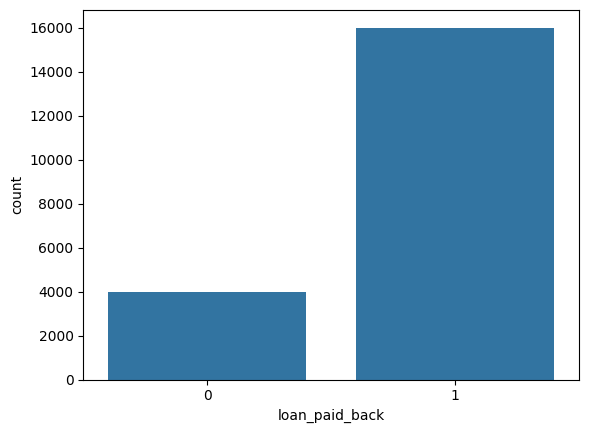

In [6]:
sns.countplot(data = df , x = 'loan_paid_back')

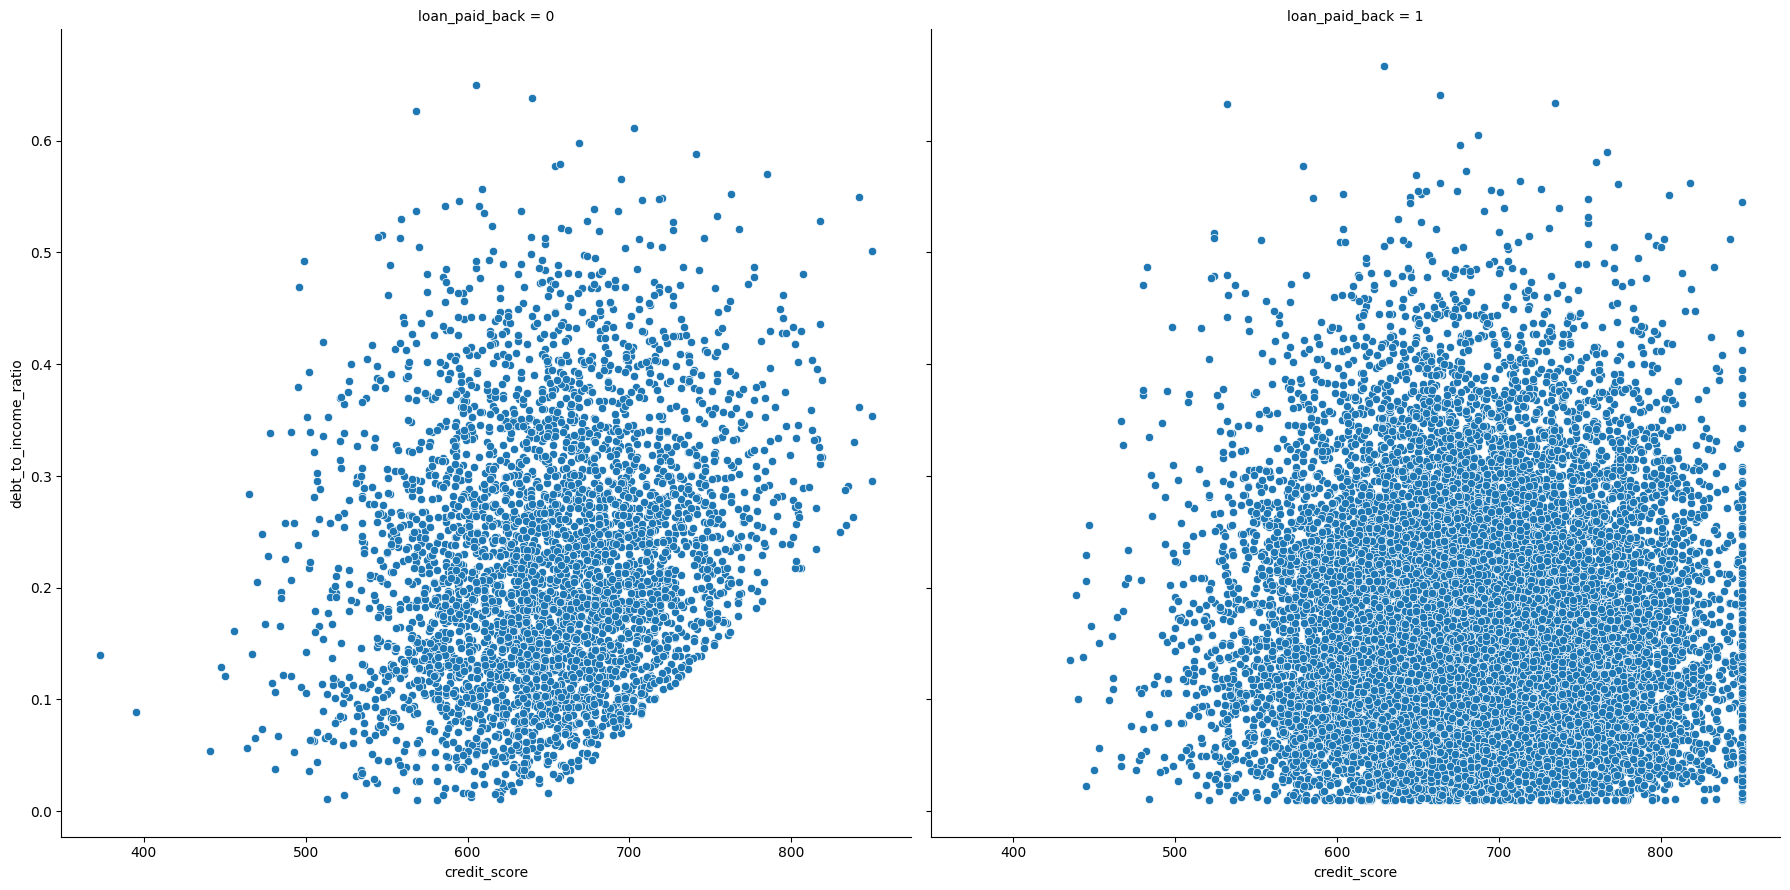

In [7]:
sns.relplot(data = df , x = 'credit_score' , y = 'debt_to_income_ratio',
            col = 'loan_paid_back', kind = 'scatter',
            height = 9 )

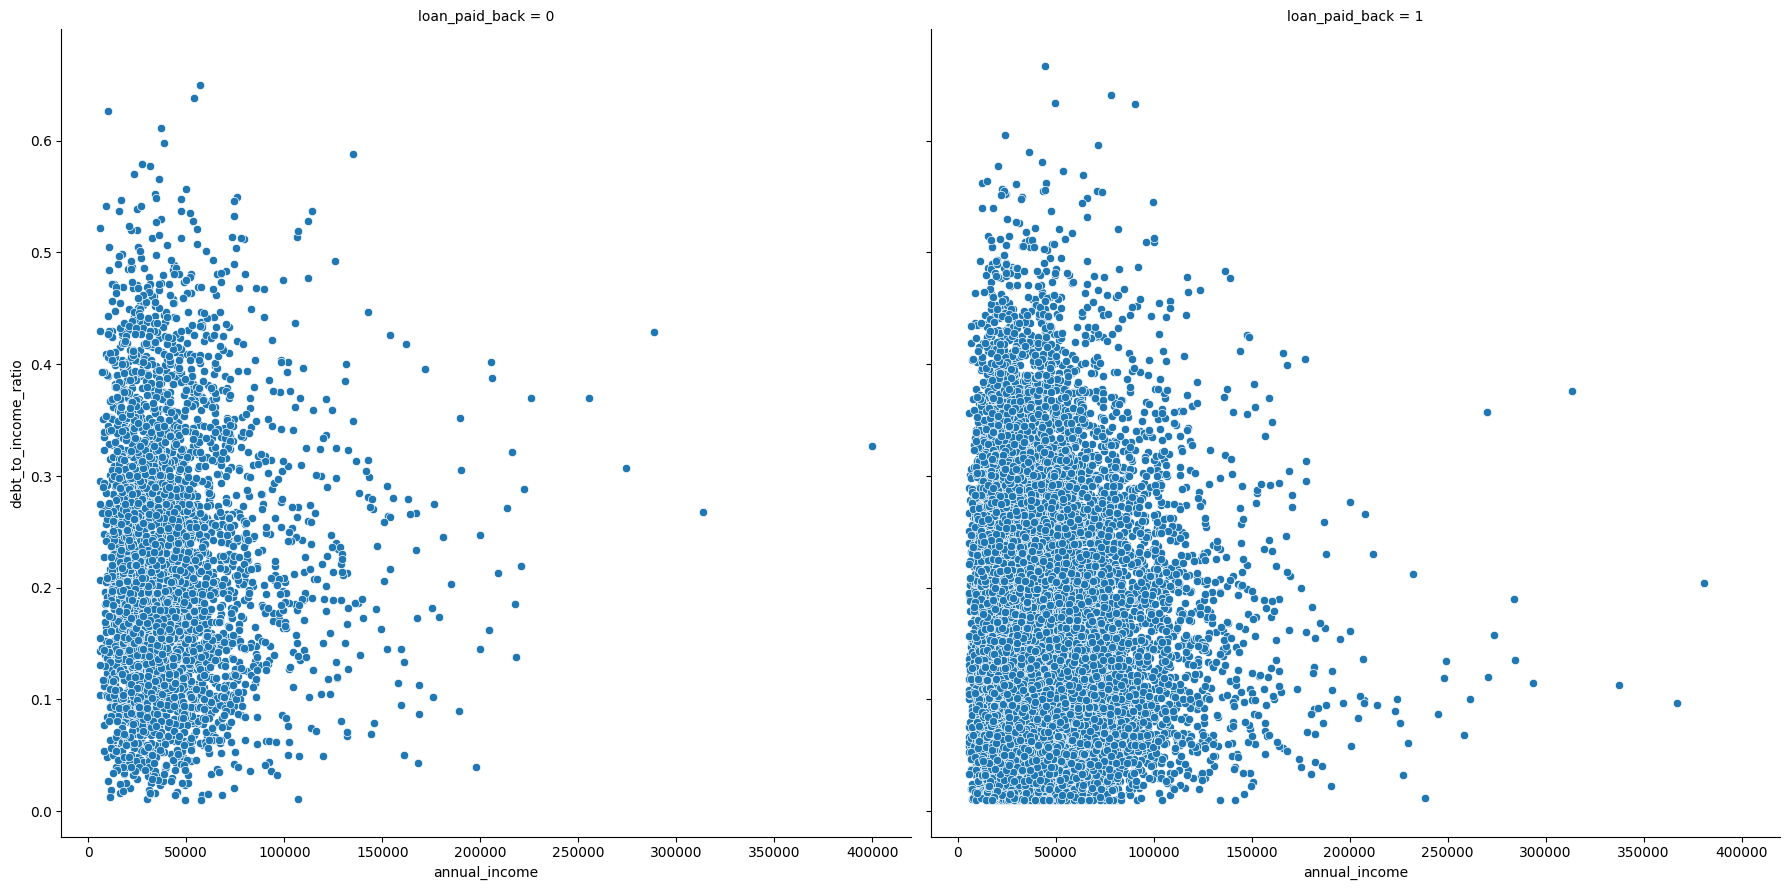

In [8]:
sns.relplot(data = df , x = 'annual_income' , y = 'debt_to_income_ratio',
            col = 'loan_paid_back', kind = 'scatter',
            height = 9 )

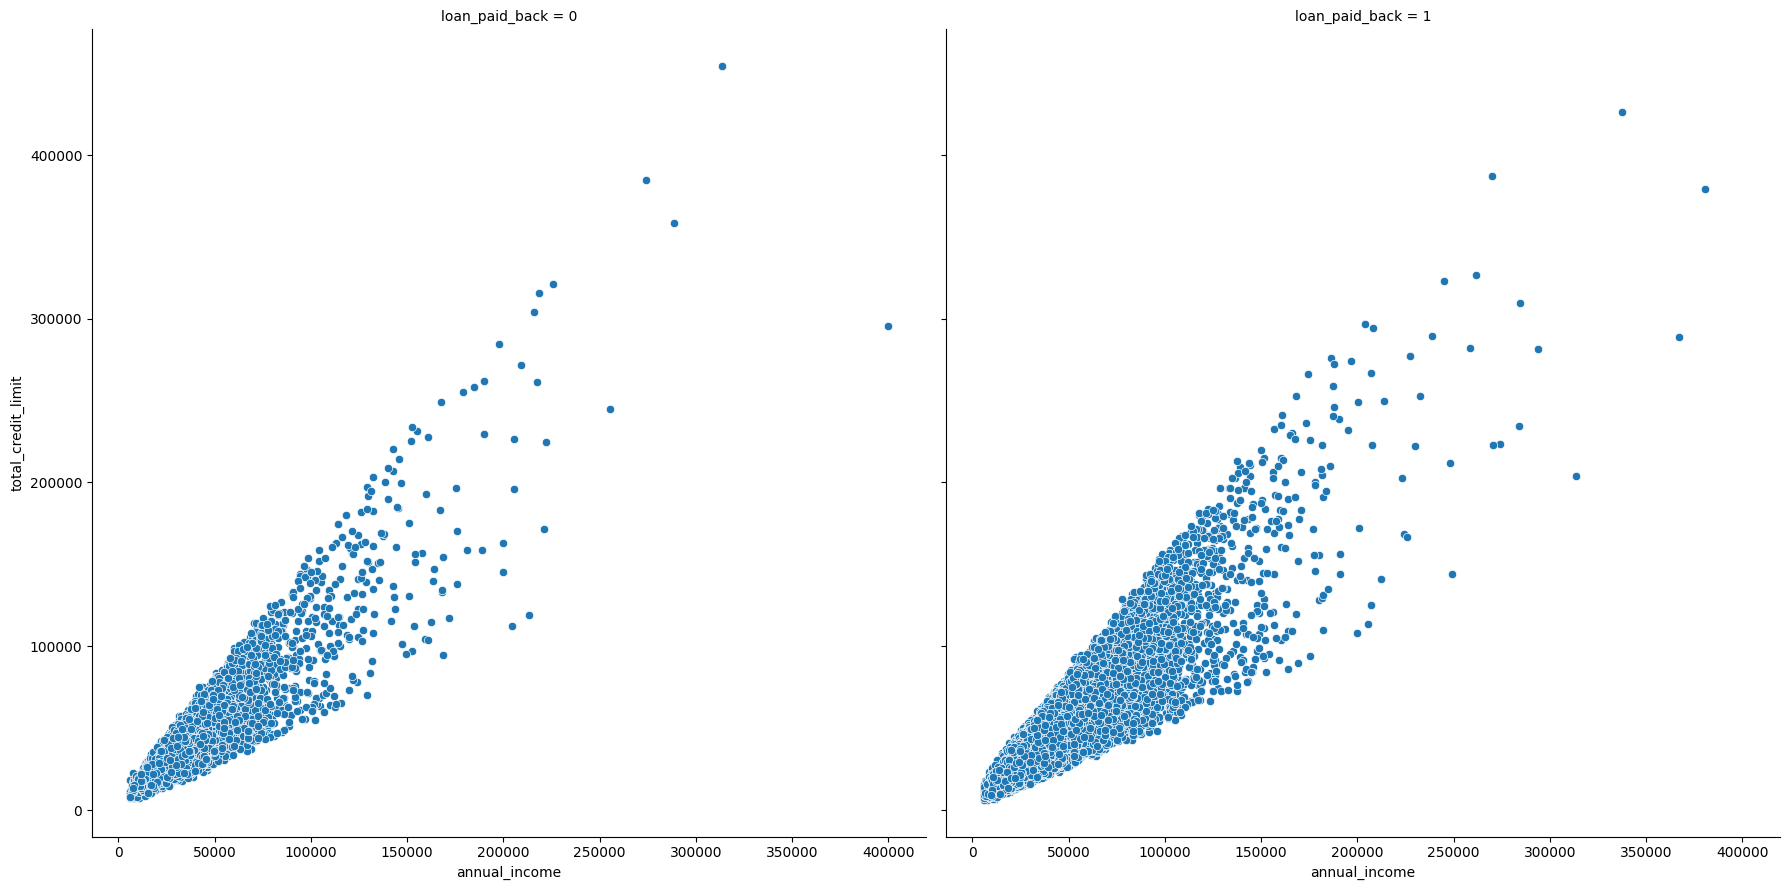

In [19]:
sns.relplot(data = df , x = 'annual_income' , y = 'total_credit_limit',
            col = 'loan_paid_back', kind = 'scatter',
            height = 9 )

#### Here we can see thta DTI is not a very good factor for predicting whether the person will pay the loan back or not, even people with low DTI have also not paid the loan back.


## Categorical data

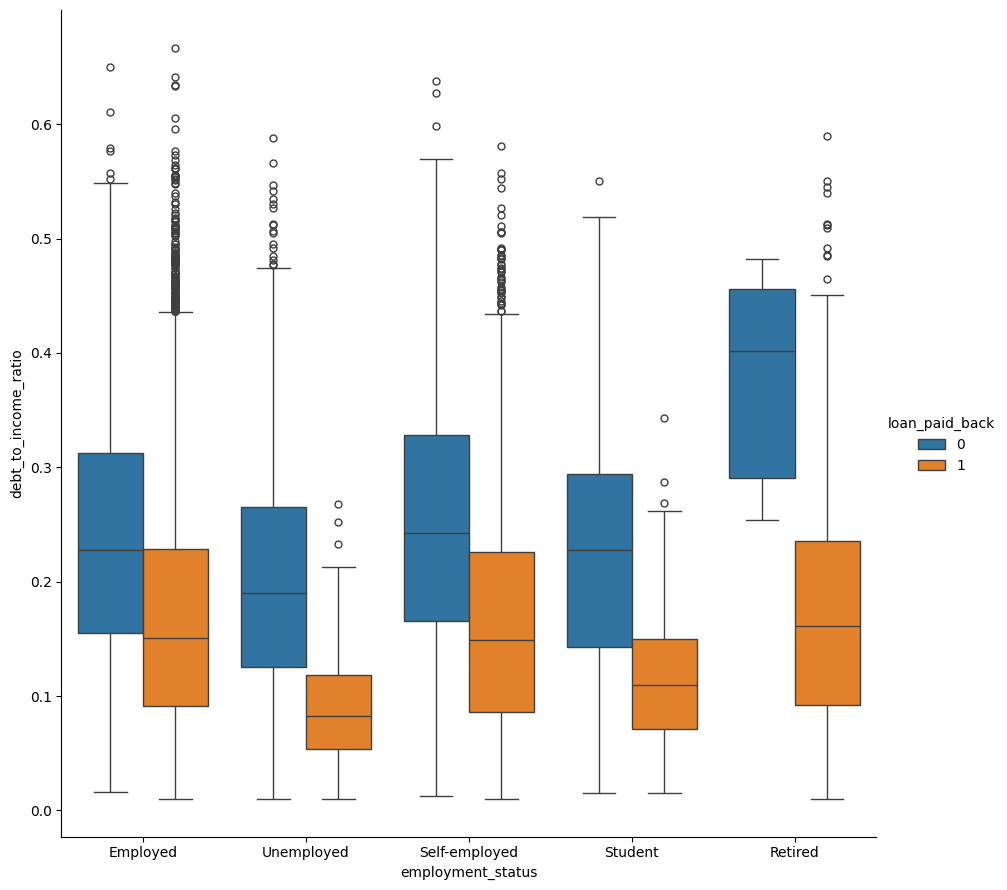

In [9]:
sns.catplot(data = df , x = 'employment_status', y = 'debt_to_income_ratio', hue = 'loan_paid_back',kind = 'box',height = 9)

## Pivot Table

In [10]:
df.columns

Index(['age', 'gender', 'marital_status', 'education_level', 'annual_income',
       'monthly_income', 'employment_status', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate',
       'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts',
       'total_credit_limit', 'current_balance', 'delinquency_history',
       'public_records', 'num_of_delinquencies', 'loan_paid_back'],
      dtype='object')

In [14]:
numeric_cols = df.select_dtypes(include = ['int64','float64']).columns
cat_cols = df.select_dtypes(include = ['object']).columns

In [15]:
numeric_cols

Index(['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'interest_rate', 'loan_term',
       'installment', 'num_of_open_accounts', 'total_credit_limit',
       'current_balance', 'delinquency_history', 'public_records',
       'num_of_delinquencies', 'loan_paid_back'],
      dtype='object')

In [ ]:
df.pivot_table(index = 'loan_paid_back',values = 'credit_score')

,credit_score
loan_paid_back,
0,651.433033
1,686.217277


In [17]:
df.pivot_table(index = 'loan_paid_back',values = ['credit_score','debt_to_income_ratio','loan_amount','total_credit_limit'])

,credit_score,debt_to_income_ratio,loan_amount,total_credit_limit
loan_paid_back,,,,
0,651.433033,0.224034,15172.134793,48843.329373
1,686.217277,0.165258,15118.585744,48601.418379


#Winsorization
##### Conclusions from the We can see in numerical dataset the features has so many outliers,now we will apply winsorization to apply caps on the dataset. We can't delete the outliers because it's credit risk dataset and these outliers are customers

In [20]:
def winsorize_series(series, lower=0.01, upper=0.99):
    lower_bound = series.quantile(lower)
    upper_bound = series.quantile(upper)
    return series.clip(lower_bound, upper_bound)

for col in numeric_cols:
    if col != 'loan_paid_back':
        df[col] = winsorize_series(df[col])


## Boxplot after Winsorization

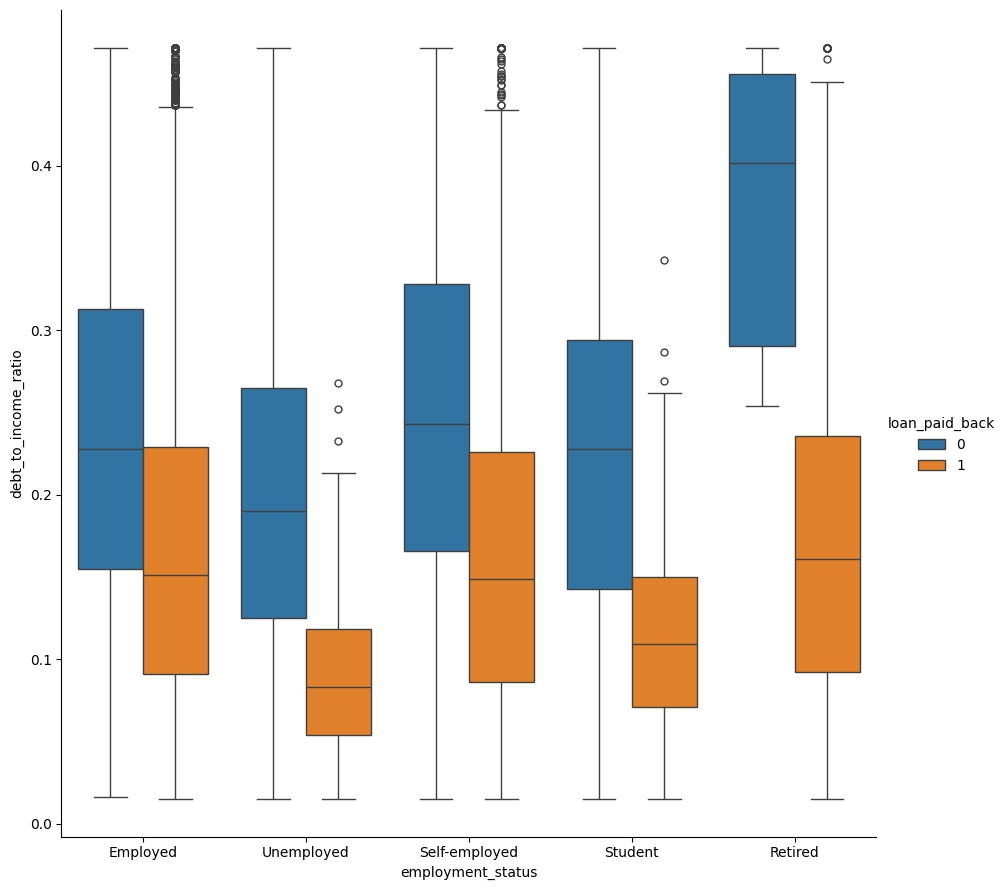

In [21]:
sns.catplot(data = df , x = 'employment_status', y = 'debt_to_income_ratio', hue = 'loan_paid_back',kind = 'box',height = 9)

## Correlation Matrix

- Since we have removed the outliers,now we can move to next step
- Let's find out how the variables are correlated with each other

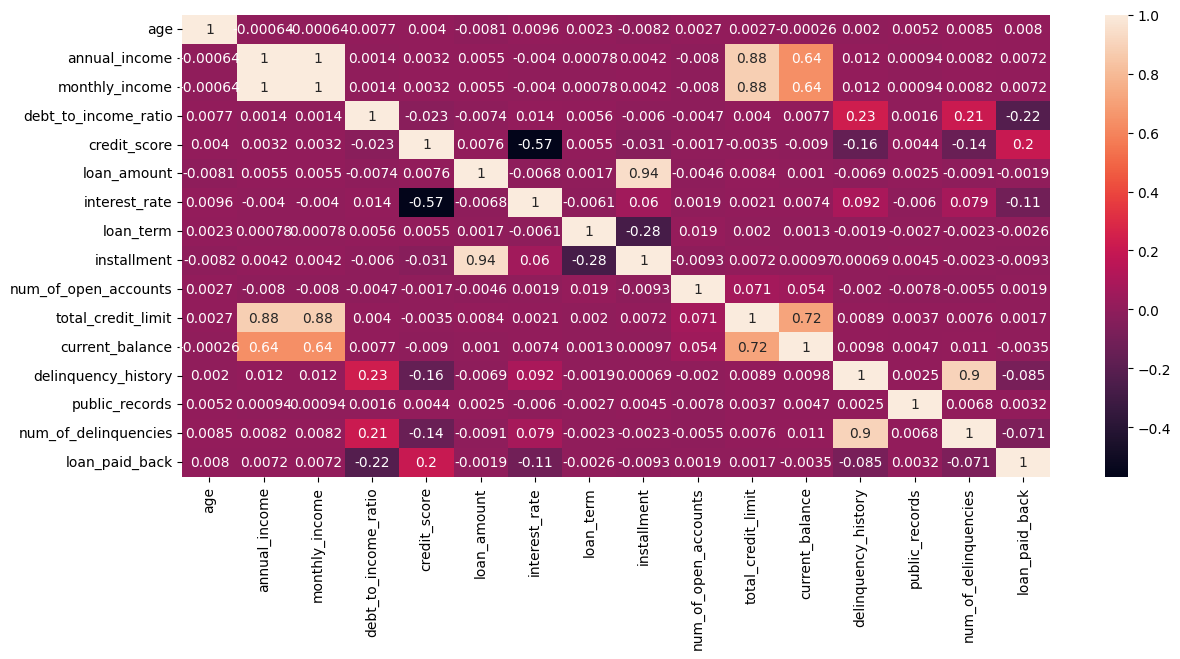

In [23]:
fig = plt.gcf() # Get current figure
fig.set_size_inches(14, 6) # Adjust size in inches
sns.heatmap(df[numeric_cols].corr(),annot = True)
plt.show()

- Here we can see that there is a very strong correlation between `annual income` and `monthly income` equal to 1.
- `loan_amount` and `installment` equals to 0.94.
- `deliquency history` and `num of deliquencies` equals to 0.9.
- `annual income` and `total credit limit` equals to 0.88.

- Multicollinearity between variables is not a problem unless we are doing inference. multicoliinearity does not contain any problem in prediction.
- Since `installment` is made from loan amount , we can drop it. In the same way we can drop other columns.

### Rather than manually dropping the columns lets calculate VIF

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[numeric_cols].drop(columns = ['loan_paid_back'])

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

                 feature           VIF
0                    age  9.977081e+00
1          annual_income  2.100070e+12
2         monthly_income  2.100070e+12
3   debt_to_income_ratio  4.108120e+00
4           credit_score  3.925471e+01
5            loan_amount  1.412375e+02
6          interest_rate  2.937481e+01
7              loan_term  5.924306e+01
8            installment  1.398813e+02
9   num_of_open_accounts  6.258148e+00
10    total_credit_limit  2.027396e+01
11       current_balance  4.923551e+00
12   delinquency_history  1.567095e+01
13        public_records  1.047426e+00
14  num_of_delinquencies  1.817092e+01


- I checked multicollinearity using VIF. Extremely high values indicated derived variables like monthly income and installment. I removed those to stabilize the model.

- installment = loan_amount × interest_rate / loan_term
- annual_income = monthly_income × 12

In [ ]:
df.drop(columns = ['installment','monthly_income','delinquency_history'],inplace = True,axis = 1)

In [33]:
df.shape

(20000, 22)

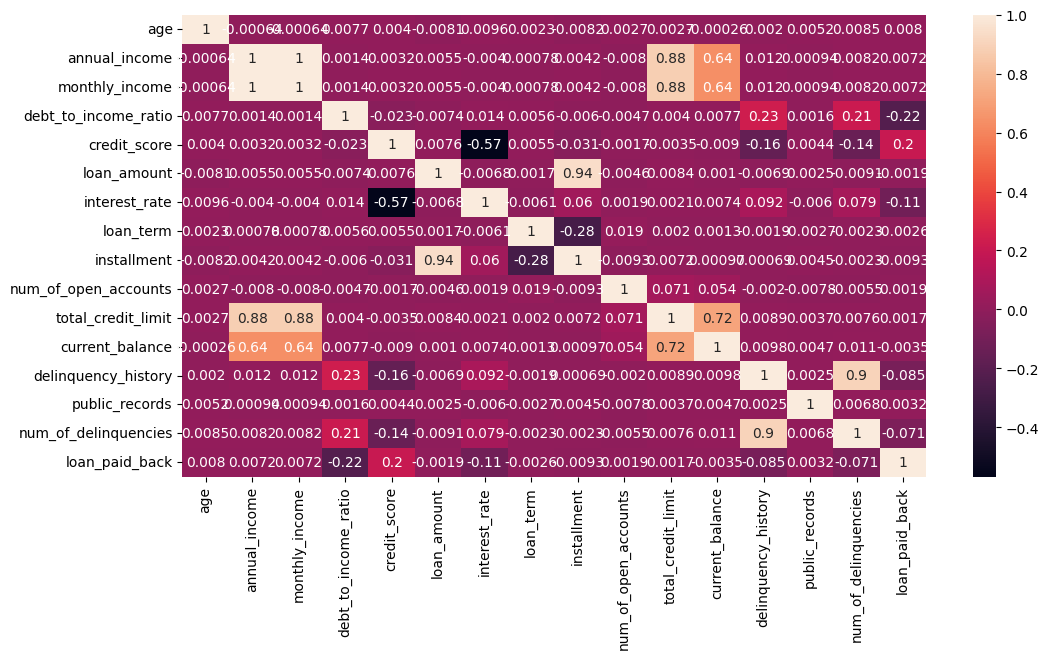

In [34]:
fig = plt.gcf() # Get current figure
fig.set_size_inches(12, 6) # Adjust size in inches
numeric_cols = df.select_dtypes(include = ['int64','float64']).columns # Update numeric_cols after dropping columns
sns.heatmap(df[numeric_cols].corr(),annot = True)
plt.show()

## Numerical values playing role in prediction

####Factors associates with default
- Higher interest rate
- Higher debt-to-income ratio
- More delinquencies
- Lower credit score

####Factors associated with successful repayment
- Higher credit score
- Lower DTI
- Fewer delinquencies
- Lower interest rate

### Now we find out if categorical values play a role in prediction by performing chi square test, since the dataset approves all the rules of chi square test

In [35]:
import pandas as pd
from scipy.stats import chi2_contingency

target = "loan_paid_back"

results = []

for col in cat_cols: # Changed categorical_cols to cat_cols
    contingency = pd.crosstab(df[col], df[target])

    chi2, p, dof, expected = chi2_contingency(contingency)

    min_expected = expected.min()
    percent_less_than_5 = (expected < 5).sum() / expected.size * 100

    results.append({
        "Variable": col,
        "Min Expected": min_expected,
        "% Cells < 5": percent_less_than_5
    })

results_df = pd.DataFrame(results)
print(results_df)

            Variable  Min Expected  % Cells < 5
0             gender       86.0430          0.0
1     marital_status      113.4567          0.0
2    education_level      160.8804          0.0
3  employment_status      156.2781          0.0
4       loan_purpose      121.4607          0.0
5     grade_subgrade       30.0150          0.0


In [36]:
from scipy.stats import chi2_contingency
target = "loan_paid_back"

results = []

for col in cat_cols:
    contingency = pd.crosstab(df[col], df[target])

    chi2, p, dof, expected = chi2_contingency(contingency)

    n = contingency.sum().sum()
    r, k = contingency.shape

    # Cramer's V calculation
    cramers_v = np.sqrt(chi2 / (n * (min(r-1, k-1))))

    results.append({
        "Variable": col,
        "Chi2": chi2,
        "p_value": p,
        "Cramers_V": cramers_v
    })

results_df = pd.DataFrame(results)

# Sort by strength of association
results_df = results_df.sort_values(by="Cramers_V", ascending=False)

print(results_df)

            Variable         Chi2        p_value  Cramers_V
3  employment_status  6827.404056   0.000000e+00   0.584269
5     grade_subgrade   763.464159  5.269055e-142   0.195380
4       loan_purpose    15.721000   2.779123e-02   0.028037
2    education_level    10.498005   3.282448e-02   0.022911
1     marital_status     1.081855   7.814561e-01   0.007355
0             gender     0.883581   6.428842e-01   0.006647


##Conclusions

| Variable              | p-value | Cramér’s V | Strength         |
| --------------------- | ------- | ---------- | ---------------- |
| **employment_status** | 0.000   | **0.584**  | 🔥 Strong        |
| **grade_subgrade**    | 0.000   | 0.195      | 🟡 Weak–Moderate |
| loan_purpose          | 0.027   | 0.028      | Very Weak        |
| education_level       | 0.033   | 0.023      | Very Weak        |
| marital_status        | 0.781   | 0.007      | None             |
| gender                | 0.643   | 0.006      | None             |


- Lets drop the values which lay no contribution in prediction

In [37]:
df.drop(columns = ['marital_status','gender'],inplace = True , axis = 1)

In [38]:
df.shape

(20000, 20)

In [39]:
df.to_csv('credit_data.csv' , sep = ',',index = False)